# Comparison of numeric method to the analytical solution found in ref[1]


In [56]:
import qsp_rs as qsp
import matplotlib.pyplot as plt
import numpy as np

### Results of ref[1]

When looking at not the entire JC-hamiltonian but instead the 2nd order pertubation terms, an analytical solution exists for finding the symmetric phases that describe a GP(r,k) polynomial:

> By fitting the optimal phase sequences $\phi_r$ to trigonometric functions, we find simple analytical expressions that fit the optimized phases. Denoting  $\phi_r = (\phi^\text{edge}_r, \vec \Phi^\text{bulk}_r, \phi^\text{edge}_r)$, we find $$\begin{aligned} \left ( \vec \Phi^\text{bulk}_r \right )_j &= \phi^\text{bulk}_r(x_j)=\frac{4}{\pi r} \left [ 1+\frac 12 \cos \left ( \frac 4r x_j \right ) \right ] \\ \phi^\text{edge}_r &= \frac 12 \left [ \frac \pi 2 - \sum^{r-1}_{j=1} \left ( \vec \Phi^\text{bulk}_r \right )_j \right] \end{aligned}$$ where $x_j = j - \left \lceil \frac r2 \right \rceil$ with $j \in \{1, \dots, \bar r\}$, and $\bar r \equiv 2 \times \left ( \left \lceil \frac r2 \right \rceil - 1 \right)$

In [57]:
def x_j(j, r):
    return j - np.ceil(r/2)

def phi_bulk_j(r, j):
    return (4/(np.pi * r)) * (1 + 0.5 * np.cos((4/r)*x_j(j, r)))

def phi_edge(r):
    return 1/2 * ((np.pi / 2) - sum([phi_bulk_j(r,j) for j in range(1,r+1)], 0))

def get_phi_r(r: int):
    arr = np.array([phi_edge(r)] + [phi_bulk_j(r,j) for j in range(1, int(2*(np.ceil(r / 2)-1)+2))] + [phi_edge(r)])
    arr[0] += np.pi / 2
    print(f"Total phases for r={r}: {len(arr)}")
    return arr
    
def do_mirror(phases):
    l = len(phases) -1 if len(phases) % 2 != 0 else 0
    n = np.concatenate((phases, phases[:l][::-1]))
    assert (len(n) // 2) + 1 == len(phases), f"Invalid length: {len(phases)} vs {(len(n) // 2) + 1}, l={l}"
    n[0] += np.pi / 2
    return np.array(n)



In [58]:
def signal_operator_z(x):
    arg = 1j * (np.arccos(x))
    return np.array([[np.exp(arg), 0], [0, np.exp(-arg)]])

def x_rotation(phi):
    return np.array([[np.cos(phi), (1j)*np.sin(phi)], [(1j)*np.sin(phi), np.cos(phi)]])

def qsp_unitary_i(phases, x):
    assert len(phases) > 1, "need at least 2 phases!"
    U = x_rotation(phases[0])
    for phi in phases[1:]:
        U = U @ signal_operator_z(x) @ x_rotation(phi)
    return U

def qsp_polynomial_i(phases, xs):
    return np.array([qsp_unitary_i(phases, x)[0][0] for x in xs])

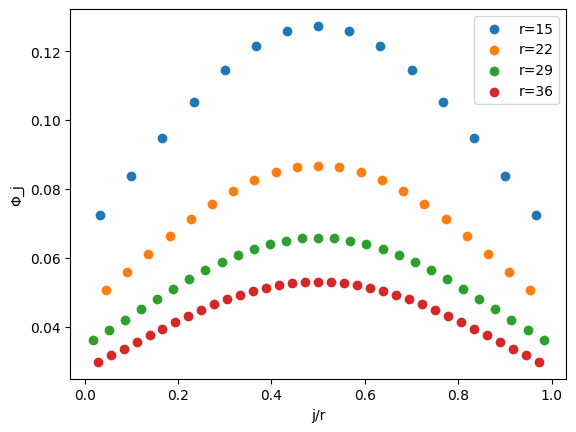

Total phases for r=8: 9
Total phases for r=13: 15
Total phases for r=41: 43


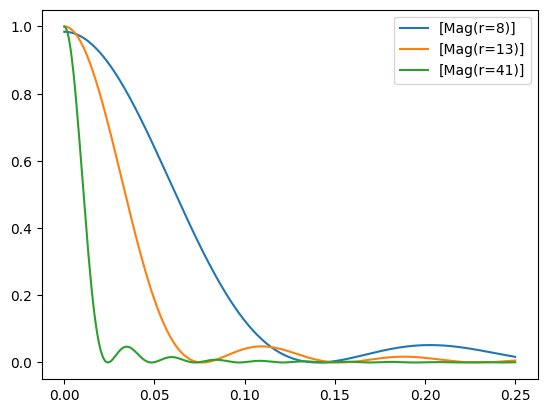

Total phases for r=12: 13
Total phases for r=13: 15


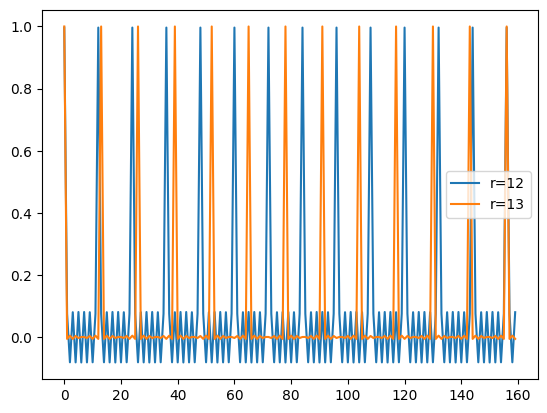

In [59]:

def calc_residual(phases, r):
    ks = range(0,r)
    thetas = [((k % r) / r) * (np.pi) for k in ks]
    xs = np.cos(thetas)
    ys = qsp.evaluate_poly(phases, xs)
    errors = [np.pow(np.abs((-1 if i % r == 0 else 0) - y), 2) for (i,y) in enumerate(ys)]
    res = sum(errors) / len(errors)
    return res

def plt_phases_rs(rs):
    for r in rs:
        x_j_by_r = [x_j(j,r) / r + 0.5 for j in range(1, int(2*(np.ceil(r / 2)-1))+2)]
        phi_j = [phi_bulk_j(r, j+1) for j in range(len(x_j_by_r))]
        plt.scatter(x_j_by_r, phi_j, label=f"r={r}")
    plt.legend()
    plt.xlabel("j/r")
    plt.ylabel("Φ_j")
    plt.show()

def f_phases(f, phis, label):
    nr_phases = len(phis)
    f.scatter(range(nr_phases), phis, label=label)

def plt_all_phases_rs(rs):
    for r in rs:
        phis = get_phi_r(r)
        f_phases(plt, phis, f"r={r}")
    plt.legend()
    plt.show()

def f_poly_transform(f, phis, label, real=False, imag=False, mag=True):
    thetas_over_pi = np.linspace(0, .25, 300)
    xs = np.array([np.cos(t * np.pi) for t in thetas_over_pi])
    if real: 
        f.plot(thetas_over_pi, qsp_polynomial_i(phis, xs).real * -1, label=f"[Re({label})] * -1")
    if imag:
        f.plot(thetas_over_pi, qsp_polynomial_i(phis,xs).imag, label=f"[Im({label})]"),
    if mag:
        f.plot(thetas_over_pi, np.pow(qsp_polynomial_i(phis,xs).imag, 2) + np.pow(qsp_polynomial_i(phis,xs).real, 2), label=f"[Mag({label})]"),

def plt_poly_transform_rs(rs):
    for r in rs:
        phis = get_phi_r(r)
        f_poly_transform(plt, phis, f"r={r}")
    plt.legend()    
    plt.show()

def f_poly_by_k(f, phis, r, label, n_half = 160):
    ks = np.arange(0,n_half)
    thetas = [((k % r) / r) * (np.pi) for k in ks]
    xs = np.cos(thetas)
    f.plot(ks, -1 * qsp_polynomial_i(phis, xs).real, label=label)
    

def plt_poly_by_k_rs(rs):
    for r in rs:
        phis = get_phi_r(r)
        f_poly_by_k(plt, phis, r, f"r={r}")
    plt.legend()
    plt.show()

plt_phases_rs([15, 22,29,36])
#plt_all_phases_rs([15])
plt_poly_transform_rs([8,13,41])
plt_poly_by_k_rs([12,13])

7
Phases solved len=15 for r=13, error: SolveResult(cost=1.248e-1, n_phases=15, total_phase=0.8702151646658149, iterations=28, termination='converged', elapsed_ms=3.4)
Total phases for r=13: 15
Solver residual: 0.002548215274777147
Analytical residual: 1.6183706384789218e-05


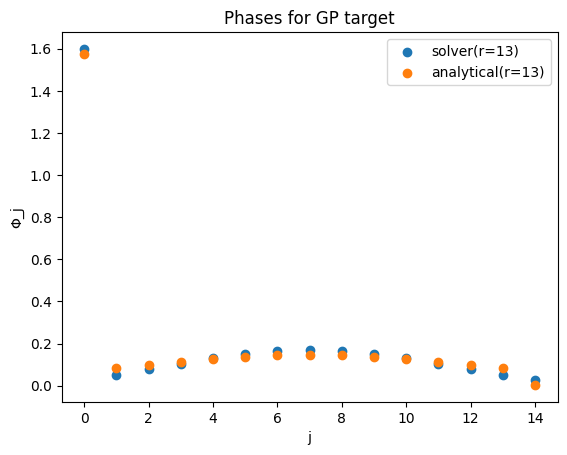

7
Phases solved len=15 for r=13, error: SolveResult(cost=1.248e-1, n_phases=15, total_phase=0.8702151646658149, iterations=28, termination='converged', elapsed_ms=3.0)
Total phases for r=13: 15


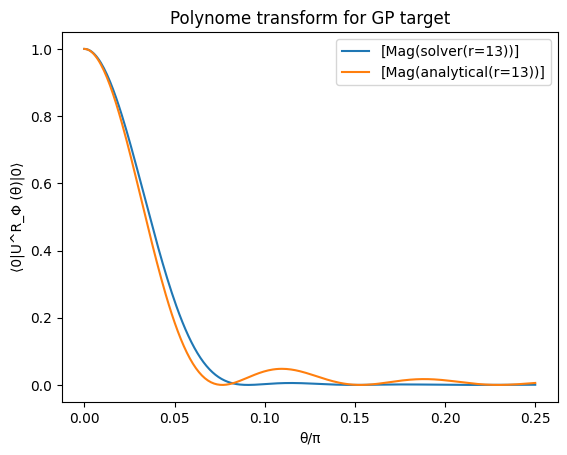

7
Phases solved len=15 for r=13, error: SolveResult(cost=1.248e-1, n_phases=15, total_phase=0.8702151646658149, iterations=28, termination='converged', elapsed_ms=3.2)
Total phases for r=13: 15


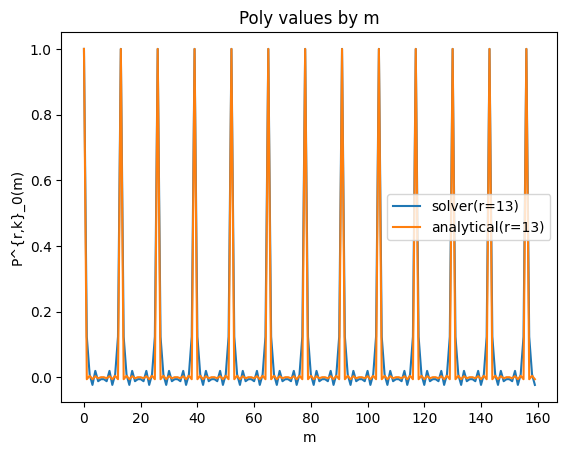

In [60]:
def find_phases_with_optimizer(r):
    d = int(np.ceil((r + (r%2)) / 2))
    #d=r+(r%2)
    print(d)
    res = qsp.solve_poly(
        [-1] + [0] * (r-1),
        target_dist="e",
        solver="lm",
        mode=f"s,{d}",
        phase_map="mirror",
        init="0"
    )
    print(f"Phases solved len={len(res.phases)} for r={r}, error: {res}")
    return res.phases

def plt_compare_optimizer_analytic_rs(rs):
    plt.title("Phases for GP target")
    plt.xlabel("j")
    plt.ylabel("Φ_j")
    for r in rs:
        phis_solver = find_phases_with_optimizer(r)
        phis_analyt = get_phi_r(r)

        print(f"Solver residual: {calc_residual(phis_solver, r)}")
        print(f"Analytical residual: {calc_residual(phis_analyt, r)}")

        f_phases(plt, phis_solver, f"solver(r={r})")
        f_phases(plt, phis_analyt, f"analytical(r={r})")
    plt.legend()
    plt.show()

    plt.title("Polynome transform for GP target")
    plt.xlabel("θ/π")
    plt.ylabel("⟨0|U^R_Φ (θ)|0⟩")
    for r in rs:
        phis_solver = find_phases_with_optimizer(r)
        phis_analyt = get_phi_r(r)
        
        f_poly_transform(plt, phis_solver, f"solver(r={r})")
        f_poly_transform(plt, phis_analyt, f"analytical(r={r})")
    plt.legend()
    plt.show()


    plt.title("Poly values by m")
    plt.xlabel("m")
    plt.ylabel("P^{r,k}_0(m)")
    for r in rs:
        phis_solver = find_phases_with_optimizer(r)
        phis_analyt = get_phi_r(r)
        
        f_poly_by_k(plt, phis_solver, r, f"solver(r={r})")
        f_poly_by_k(plt, phis_analyt, r, f"analytical(r={r})")
    plt.legend()
    plt.show()




plt_compare_optimizer_analytic_rs([13])